In [262]:
import math
import time
import random
import numpy as np
import json
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
from bessel_zeros import get_bessel_zeros
from scipy.special import jv, jvp, gamma, loggamma
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
font = font_manager.FontProperties(style='normal', size=20)
import matplotlib.ticker as ticker
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

from bessel_zeros import get_bessel_zeros
from CDFs import build_cdfs as build_cdfs
import seaborn as sns

In [263]:
# from pathlib import Path
# path = Path.cwd()
# path

In [ ]:
# open a json file to save path lengths
d = 20
with open(f"path_length_WoC_{d}.json", 'r') as json_file:
        # Use json.load() to convert the file content into a Python dictionary
        length_dict_woc = json.load(json_file)
with open(f"p_exit_{d}.json", 'r') as json_file:
        # Use json.load() to convert the file content into a Python dictionary
        p_dict = json.load(json_file)         
with open(f"path_length_WoHB_{d}.json", 'r') as json_file:
        # Use json.load() to convert the file content into a Python dictionary
        length_dict_wohb = json.load(json_file)    
        # p_surv = [v for k, v in p_dict.items()]

In [265]:
avg_length_woc = np.array([[p_dict[s], np.mean(length)] for s, length in length_dict_woc.items()])
avg_length_wohb = np.mean(length_dict_wohb['wohb'])
avg_length = avg_length_woc.astype(float)
avg_length_wohb

10.19362

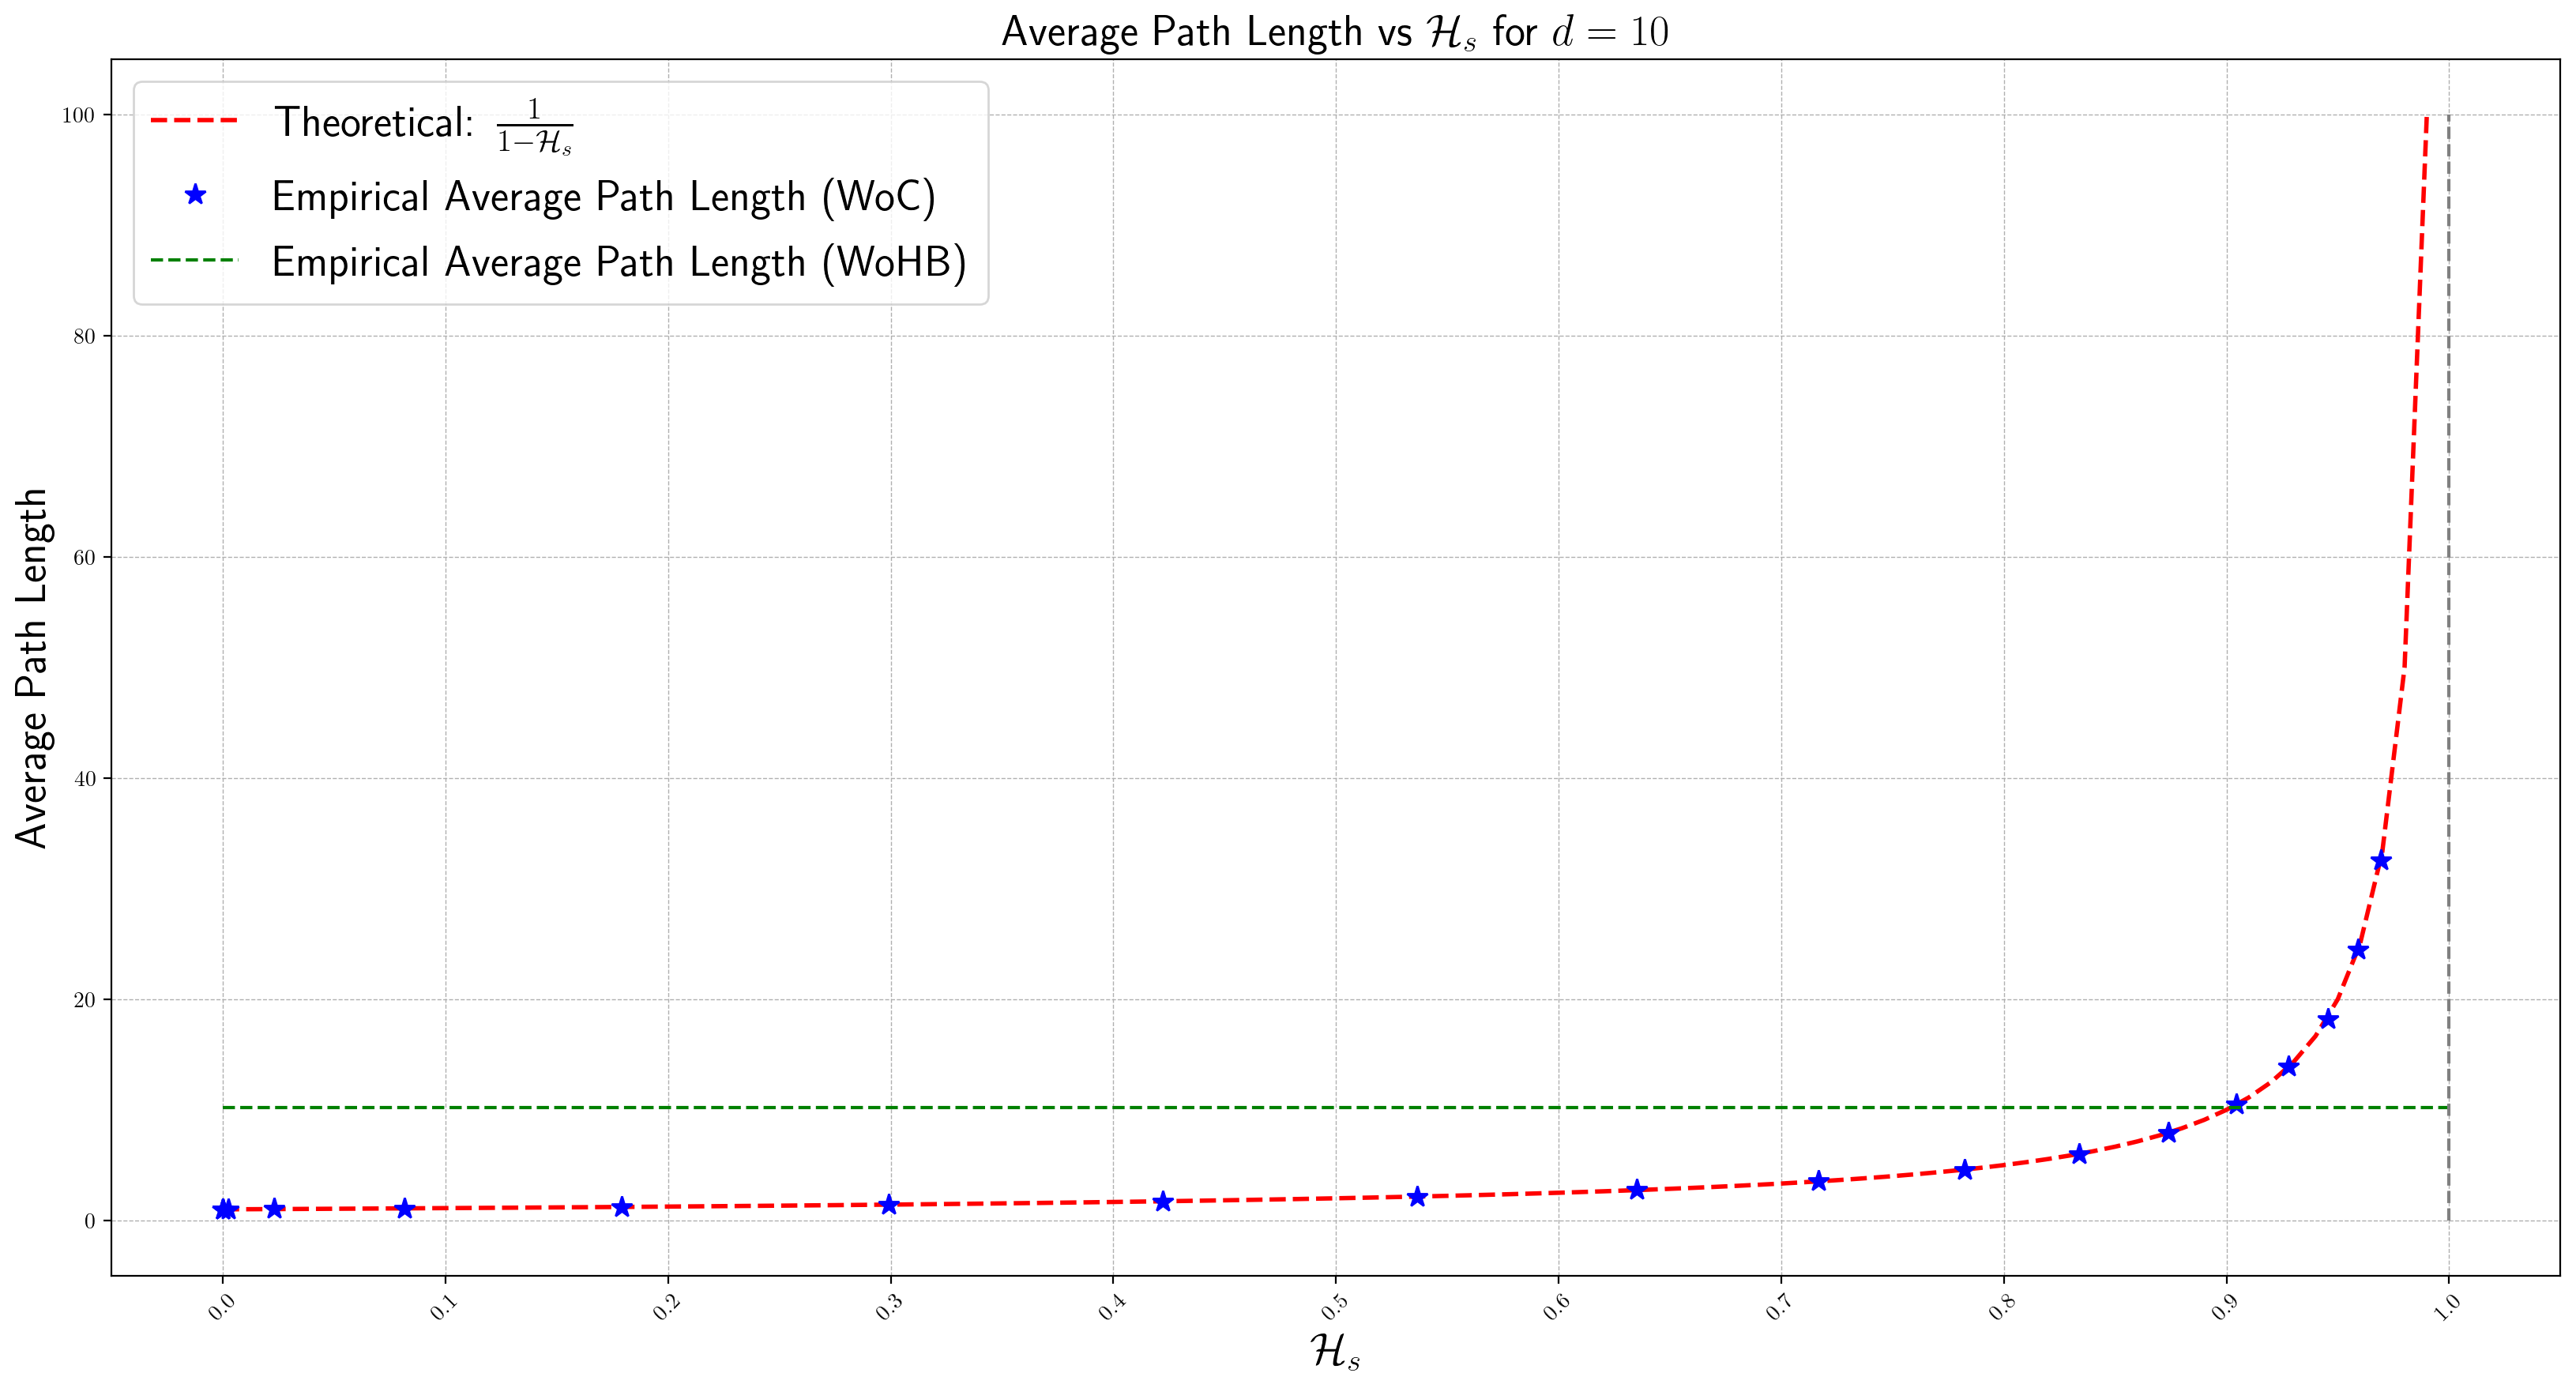

In [266]:
# ── PLOTTING ────────────────────────────────────────────────────────────────
f , ax = plt.subplots(figsize=(20, 10),dpi=200)
plt.plot(np.arange(0.,1.,0.01), (1/(1-np.array(np.arange(0.,1.,0.01)))), linewidth=2, linestyle='--', color='red', label=r'Theoretical: $\frac{1}{1-\mathcal{H}_s}$')
ax.plot(avg_length[:,0], avg_length[:,1],  marker='*', markersize=10, linewidth=0, color='blue', label='Empirical Average Path Length (WoC)')
plt.hlines(avg_length_wohb, xmin=0, xmax=1, colors='green', linestyles='dashed', label='Empirical Average Path Length (WoHB)')
plt.xlabel(r'$\mathcal{{H}}_s$', fontproperties=font)
plt.ylabel('Average Path Length', fontproperties=font)
plt.title(r'Average Path Length vs $\mathcal{{H}}_s$ for $d={}$'.format(d), fontproperties=font)
ax.set_xticks(np.arange(0.,1.1,0.1))
plt.vlines(1,ymin=0,ymax=100, colors='grey', linestyles='dashed')
plt.xticks(rotation=45);
# plt.yscale('log');
# plt.xscale('log');
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(prop=font)
plt.show()
f.savefig(f'avg_path_length_{d}.pdf',format="pdf",dpi=600)

In [267]:
H_s = np.array([[float(s),float(h)] for s, h in p_dict.items()])

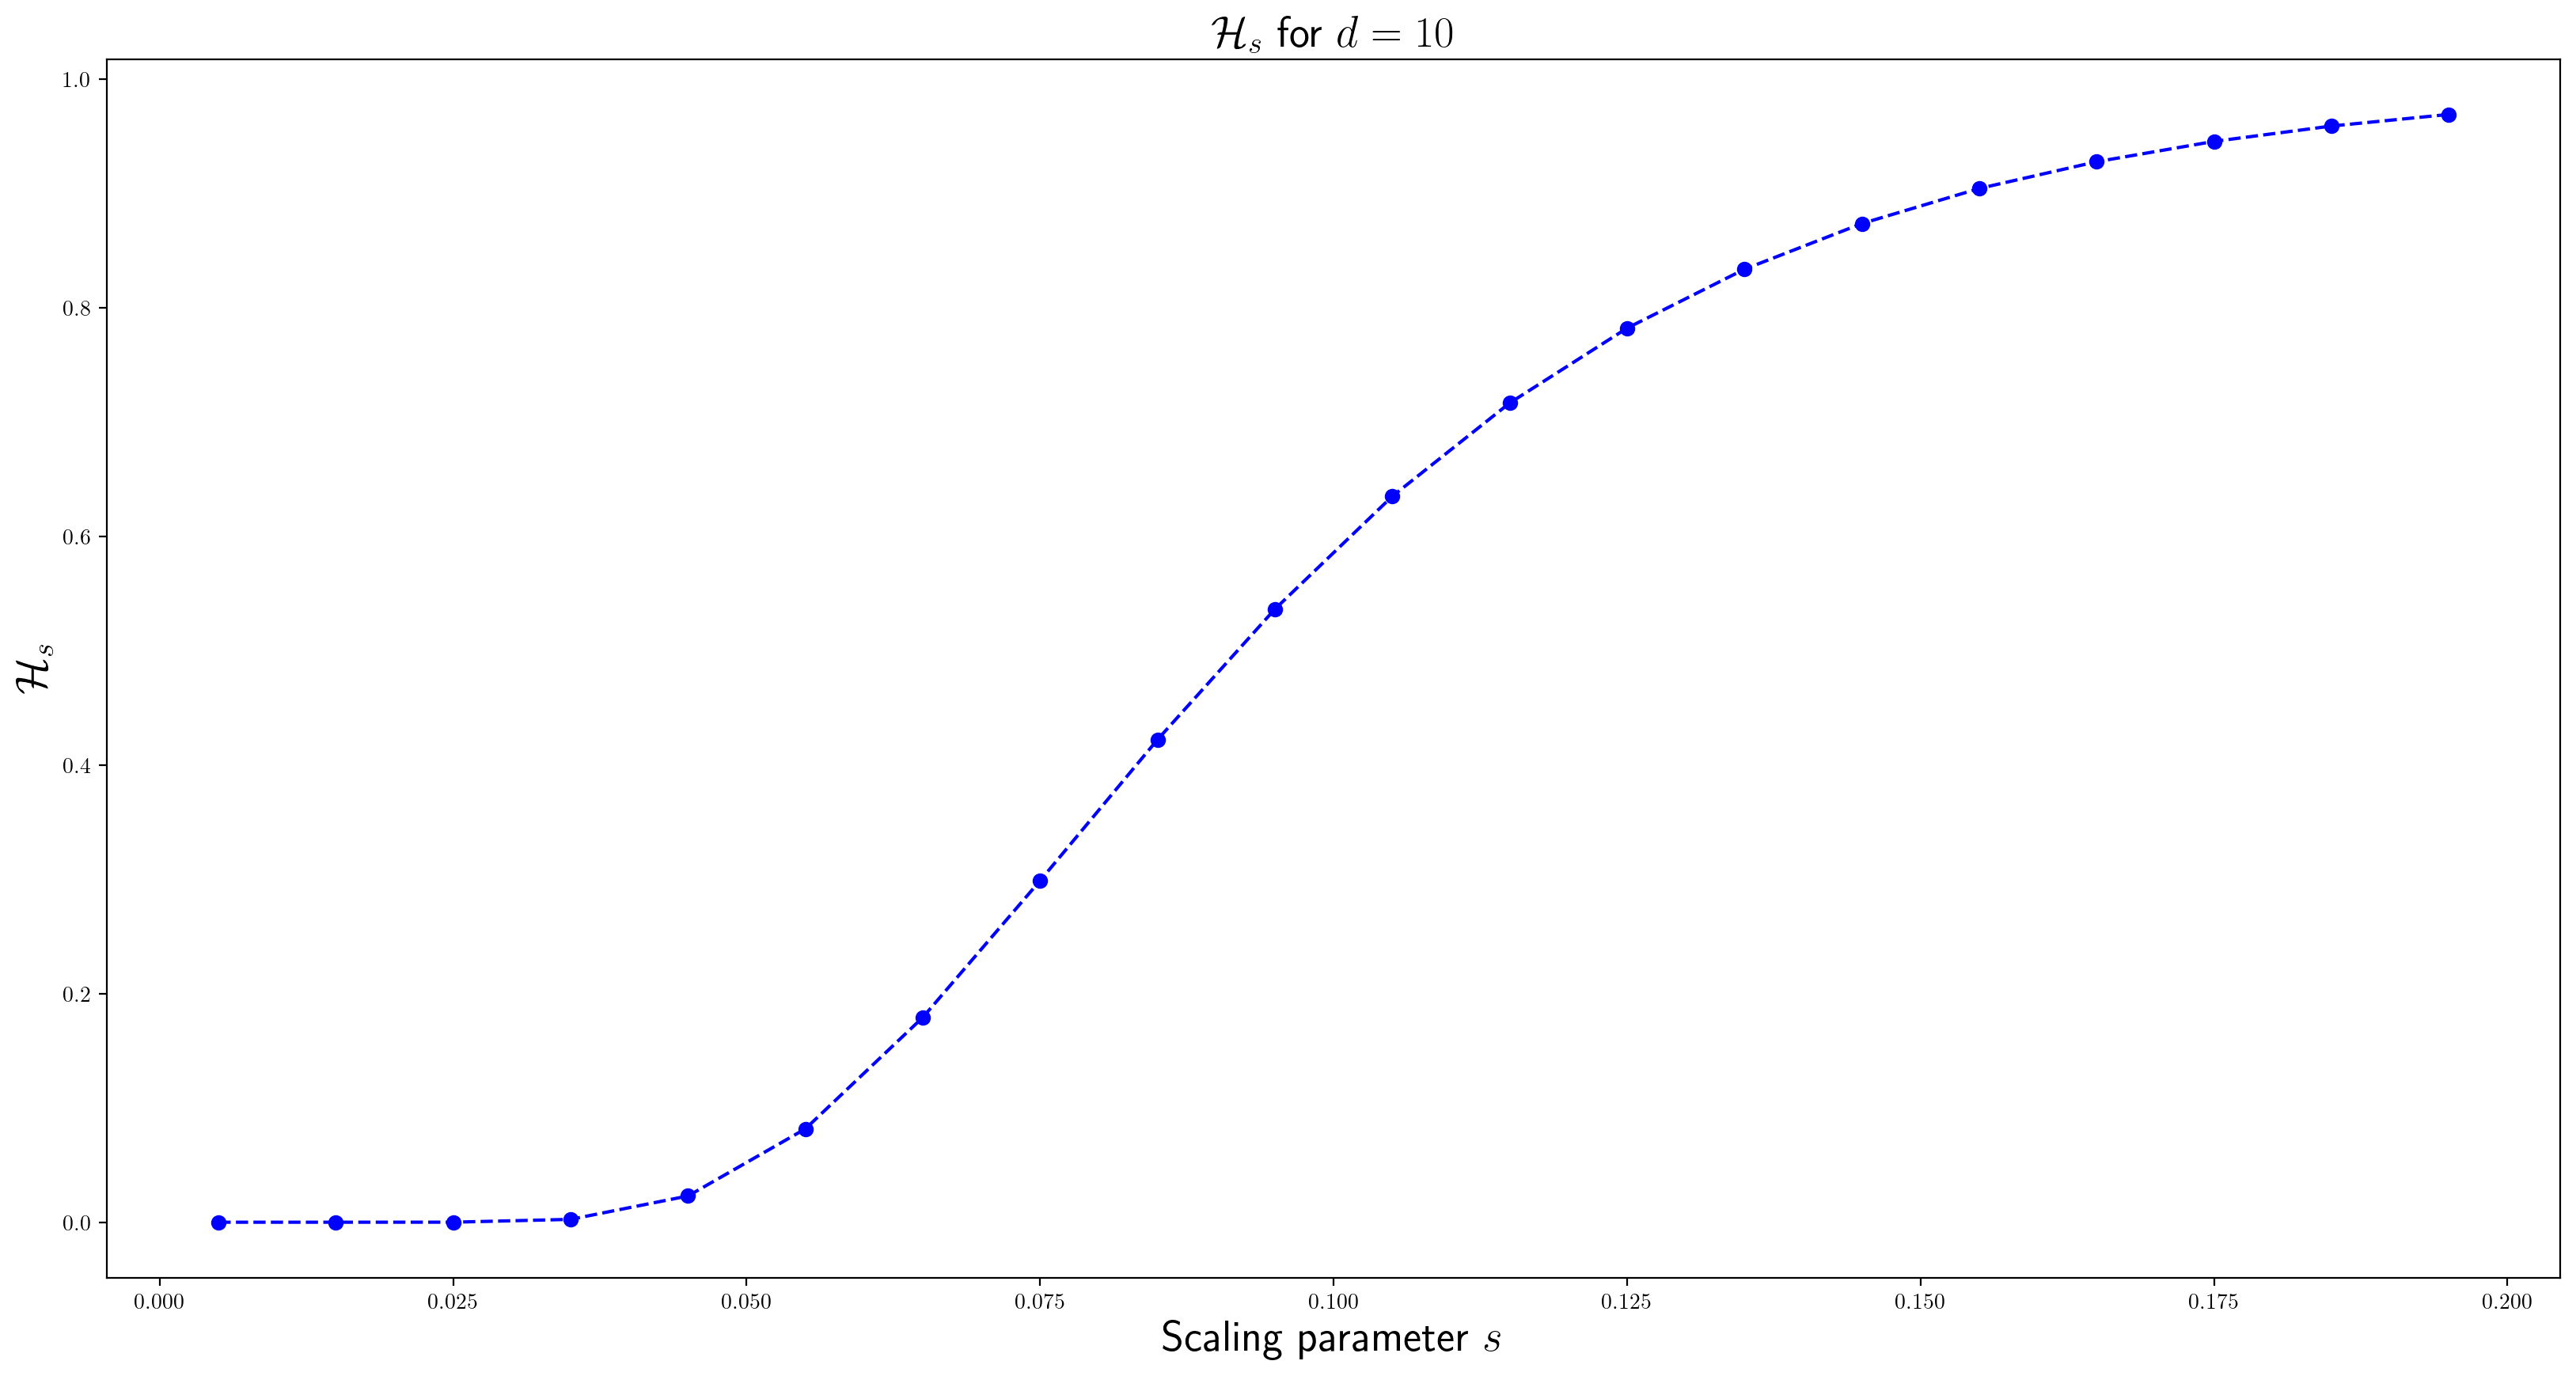

In [268]:
f , ax = plt.subplots(figsize=(20, 10),dpi=200)
ax.plot(H_s[:,0], H_s[:,1], marker='o', linestyle='--', color='blue', label=r'Exit Probability');
# xticks_locations = ax.get_xticks()
# ax.set_xticks(xticks_locations, labels=[f'{x[:4]}' for x in H_s[:,0]]);
# yticks_locations = ax.get_yticks()
# ax.set_yticks(yticks_locations, labels=[f'{float(x):.5f}' for x in H_s[:,1]]);
plt.xlabel(r'Scaling parameter $s$', fontproperties=font)
plt.ylabel(r'$\mathcal{{H}}_s$', fontproperties=font)
plt.title(r'$\mathcal{{H}}_s$ for $d={}$'.format(d), fontproperties=font)

f.savefig(f'H_s_{d}.pdf',format="pdf",dpi=600)